In [10]:
import glob
import sys
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import re
from typing import List
from dataclasses import dataclass
from sklearn.preprocessing import QuantileTransformer
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from decimal import Decimal
from IPython.core.display import Markdown
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

In [11]:
@dataclass
class ResultConfiguration:
    name: str # name that shows up in the plots
    path: str # path to the result root directory
    thresholds: List[float]
    normalize_probs: bool = False# normalize so values between 0 and 1 if set to True
    in_ode: bool | None = None # True: Only in-ODE words; False: Only out-of-ODE words, None: no filtering
    mwe: bool | None = None # True: Only MWE; False: Only SWE, None: no filtering
    no_s1: bool = False

In [12]:
# some preconfigured results

thresholds_regular = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

classifiers = [
    ResultConfiguration("Own Weights", "../results/full_run_annotation/own_dev_regular", thresholds=thresholds_regular, in_ode=None, mwe=None),
    ResultConfiguration("Finnish AXOLOTL Weights", "../results/full_run_annotation/finnish_regular", thresholds=thresholds_regular, in_ode=None, mwe=None),
    ResultConfiguration("Russian AXOLOTL Weights", "../results/full_run_annotation/russian_regular", thresholds=thresholds_regular, in_ode=None, mwe=None),
]

classifiers_no_s1 = [
    ResultConfiguration("Own Weights no S1", "../results/full_run_annotation/own_dev_regular", thresholds=thresholds_regular, in_ode=None, mwe=None, no_s1=True),
    ResultConfiguration("Finnish AXOLOTL Weights no S1", "../results/full_run_annotation/finnish_regular", thresholds=thresholds_regular, in_ode=None, mwe=None, no_s1=True),
    ResultConfiguration("Russian AXOLOTL Weights no S1", "../results/full_run_annotation/russian_regular", thresholds=thresholds_regular, in_ode=None, mwe=None, no_s1=True),
]

baselines = [
    ResultConfiguration("cosine_0", "../results/full_run_annotation/cosine_0", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=False),
    ResultConfiguration("cosine_1", "../results/full_run_annotation/cosine_1", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=False),
    ResultConfiguration("euclidean_0 (normalized [0,1])", "../results/full_run_annotation/euclidean_0", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True),
    ResultConfiguration("euclidean_1 (normalized [0,1])", "../results/full_run_annotation/euclidean_1", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True),
    ResultConfiguration("cityblock_0 (normalized [0,1])", "../results/full_run_annotation/cityblock_0", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True),
    ResultConfiguration("cityblock_1 (normalized [0,1])", "../results/full_run_annotation/cityblock_1", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True),
    ResultConfiguration("norm_l1_0 (normalized [0,1])", "../results/full_run_annotation/norm_l1_0", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True),
    ResultConfiguration("norm_l1_1 (normalized [0,1])", "../results/full_run_annotation/norm_l1_1", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True),
    ResultConfiguration("norm_l2_0 (normalized [0,1])", "../results/full_run_annotation/norm_l2_0", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True),
    ResultConfiguration("norm_l2_1 (normalized [0,1])", "../results/full_run_annotation/norm_l2_1", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True),
]

baselines_no_s1 = [
    ResultConfiguration("cosine_0 no S1", "../results/full_run_annotation/cosine_0", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=False, no_s1=True),
    ResultConfiguration("cosine_1 no S1", "../results/full_run_annotation/cosine_1", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=False, no_s1=True),
    ResultConfiguration("euclidean_0 no S1 (normalized [0,1])", "../results/full_run_annotation/euclidean_0", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True, no_s1=True),
    ResultConfiguration("euclidean_1 no S1 (normalized [0,1])", "../results/full_run_annotation/euclidean_1", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True, no_s1=True),
    ResultConfiguration("cityblock_0 no S1 (normalized [0,1])", "../results/full_run_annotation/cityblock_0", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True, no_s1=True),
    ResultConfiguration("cityblock_1 no S1 (normalized [0,1])", "../results/full_run_annotation/cityblock_1", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True, no_s1=True),
    ResultConfiguration("norm_l1_0 no S1 (normalized [0,1])", "../results/full_run_annotation/norm_l1_0", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True, no_s1=True),
    ResultConfiguration("norm_l1_1 no S1 (normalized [0,1])", "../results/full_run_annotation/norm_l1_1", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True, no_s1=True),
    ResultConfiguration("norm_l2_0 no S1 (normalized [0,1])", "../results/full_run_annotation/norm_l2_0", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True, no_s1=True),
    ResultConfiguration("norm_l2_1 no S1 (normalized [0,1])", "../results/full_run_annotation/norm_l2_1", thresholds=thresholds_regular, in_ode=None, mwe=None, normalize_probs=True, no_s1=True),
]

all_in_ode=[
    ResultConfiguration("Own Weights | in_ode=True", "../results/full_run_annotation/own_dev_regular", thresholds=thresholds_regular, in_ode=True, mwe=None),
    ResultConfiguration("Finnish AXOLOTL Weights | in_ode=True", "../results/full_run_annotation/finnish_regular", thresholds=thresholds_regular, in_ode=True, mwe=None),
    ResultConfiguration("Russian AXOLOTL Weights | in_ode=True", "../results/full_run_annotation/russian_regular", thresholds=thresholds_regular, in_ode=True, mwe=None),
    ResultConfiguration("cosine_0 | in_ode=True", "../results/full_run_annotation/cosine_0", thresholds=thresholds_regular, in_ode=True, mwe=None, normalize_probs=False),
    ResultConfiguration("cosine_1 | in_ode=True", "../results/full_run_annotation/cosine_1", thresholds=thresholds_regular, in_ode=True, mwe=None, normalize_probs=False),
    ResultConfiguration("euclidean_0 | in_ode=True", "../results/full_run_annotation/euclidean_0", thresholds=thresholds_regular, in_ode=True, mwe=None, normalize_probs=True),
    ResultConfiguration("euclidean_1 | in_ode=True", "../results/full_run_annotation/euclidean_1", thresholds=thresholds_regular, in_ode=True, mwe=None, normalize_probs=True),
    ResultConfiguration("cityblock_0 | in_ode=True", "../results/full_run_annotation/cityblock_0", thresholds=thresholds_regular, in_ode=True, mwe=None, normalize_probs=True),
    ResultConfiguration("cityblock_1 | in_ode=True", "../results/full_run_annotation/cityblock_1", thresholds=thresholds_regular, in_ode=True, mwe=None, normalize_probs=True),
    ResultConfiguration("norm_l1_0 | in_ode=True", "../results/full_run_annotation/norm_l1_0", thresholds=thresholds_regular, in_ode=True, mwe=None, normalize_probs=True),
    ResultConfiguration("norm_l1_1 | in_ode=True", "../results/full_run_annotation/norm_l1_1", thresholds=thresholds_regular, in_ode=True, mwe=None, normalize_probs=True),
    ResultConfiguration("norm_l2_0 | in_ode=True", "../results/full_run_annotation/norm_l2_0", thresholds=thresholds_regular, in_ode=True, mwe=None, normalize_probs=True),
    ResultConfiguration("norm_l2_1 | in_ode=True", "../results/full_run_annotation/norm_l2_1", thresholds=thresholds_regular, in_ode=True, mwe=None, normalize_probs=True)
]
all_out_ode=[
    ResultConfiguration("Own Weights | in_ode=False", "../results/full_run_annotation/own_dev_regular", thresholds=thresholds_regular, in_ode=False, mwe=None),
    ResultConfiguration("Finnish AXOLOTL Weights | in_ode=False", "../results/full_run_annotation/finnish_regular", thresholds=thresholds_regular, in_ode=False, mwe=None),
    ResultConfiguration("Russian AXOLOTL Weights | in_ode=False", "../results/full_run_annotation/russian_regular", thresholds=thresholds_regular, in_ode=False, mwe=None),
    ResultConfiguration("cosine_0 | in_ode=False", "../results/full_run_annotation/cosine_0", thresholds=thresholds_regular, in_ode=False, mwe=None, normalize_probs=False),
    ResultConfiguration("cosine_1 | in_ode=False", "../results/full_run_annotation/cosine_1", thresholds=thresholds_regular, in_ode=False, mwe=None, normalize_probs=False),
    ResultConfiguration("euclidean_0 | in_ode=False", "../results/full_run_annotation/euclidean_0", thresholds=thresholds_regular, in_ode=False, mwe=None, normalize_probs=True),
    ResultConfiguration("euclidean_1 | in_ode=False", "../results/full_run_annotation/euclidean_1", thresholds=thresholds_regular, in_ode=False, mwe=None, normalize_probs=True),
    ResultConfiguration("cityblock_0 | in_ode=False", "../results/full_run_annotation/cityblock_0", thresholds=thresholds_regular, in_ode=False, mwe=None, normalize_probs=True),
    ResultConfiguration("cityblock_1 | in_ode=False", "../results/full_run_annotation/cityblock_1", thresholds=thresholds_regular, in_ode=False, mwe=None, normalize_probs=True),
    ResultConfiguration("norm_l1_0 | in_ode=False", "../results/full_run_annotation/norm_l1_0", thresholds=thresholds_regular, in_ode=False, mwe=None, normalize_probs=True),
    ResultConfiguration("norm_l1_1 | in_ode=False", "../results/full_run_annotation/norm_l1_1", thresholds=thresholds_regular, in_ode=False, mwe=None, normalize_probs=True),
    ResultConfiguration("norm_l2_0 | in_ode=False", "../results/full_run_annotation/norm_l2_0", thresholds=thresholds_regular, in_ode=False, mwe=None, normalize_probs=True),
    ResultConfiguration("norm_l2_1 | in_ode=False", "../results/full_run_annotation/norm_l2_1", thresholds=thresholds_regular, in_ode=False, mwe=None, normalize_probs=True)
]

# need different mapping files and lemur_path for this
unrecorded_as_lemur =[
    ResultConfiguration("Own Weights Unrecorded", "../results_dev3_annotations_unrecorded", thresholds=thresholds_regular, in_ode=None, mwe=None),
    ResultConfiguration("Own Weights Unrecorded | in_ode=True", "../results_dev3_annotations_unrecorded", thresholds=thresholds_regular, in_ode=True, mwe=None),
    ResultConfiguration("Own Weights Unrecorded | in_ode=False", "../results_dev3_annotations_unrecorded", thresholds=thresholds_regular, in_ode=False, mwe=None),
]

In [13]:
# parameters

# list of result configurations to plot
result_inputs = classifiers #+ baselines
annotations_path = "../../../data/dev3/annotated_usages/**/*usage_sample.tsv"
mappings_path = "../../../data/dev3/annotated_usages/**/*mappings.tsv"
ode_path = "../../../data/dev3/dictionaries/ode_dictionary.tsv"
lemur_path = "../../../data/dev3/dictionaries/lemur_dictionary.tsv"

# use these if you use the unrecorded_as_lemur_results
#mappings_path = "../../../data/dev3/alternative_inputs/alternative_dictionaries/dev3_unrecorded_dictionary_mappings_MFS.tsv"
#lemur_path = "../../../data/dev3/alternative_inputs/alternative_dictionaries/dev3_unrecorded_dictionary_MFS.tsv"

#mappings_path = "../../../data/dev3/alternative_inputs/alternative_dictionaries/dev3_unrecorded_dictionary_mappings_LFS.tsv"
#lemur_path = "../../../data/dev3/alternative_inputs/alternative_dictionaries/dev3_unrecorded_dictionary_LFS.tsv"

pdf_out = "../plots/threshold_analysis/regular_lemur/regular/heatplots.pdf"  # where to save heatplots
show_sense_counts = True  # if True show number of considered senses in the calculation of the heatplots alongside the heatmaps

step_size = Decimal("0.01")
step_count = int(Decimal("1.0") / step_size)
# thresholds at which precision recall is evaluated. More fine-grained is possible here as it does not get cluttered as heatplots do for many different thresholds
per_considered_senses_thresholds = [float(i * step_size) for i in range(step_count + 1)]

html_out = "../plots/threshold_analysis/regular_lemur/regular/pr_sense_count.html" # output for plot with precision and recall in one
html_out_separate = "../plots/threshold_analysis/regular_lemur/regular/pr_sense_count_separate.html" # output for plot with precision and recall side by side
raw_result_name = "no_s1_MFS.tsv"

In [14]:
# read annotated usages
annotation_paths = glob.glob(annotations_path, recursive=True)
df_annotation = pd.concat([pd.read_csv(a, sep="\t", dtype=str, encoding="utf-8") for a in annotation_paths])
df_annotation = df_annotation[["sense_id", "identifier", "lemma"]].rename(columns={"sense_id": "annotation_id"})

# only use first named sense_id annotation
df_annotation["annotation_id"] = df_annotation["annotation_id"].apply(lambda sense_id: sense_id.split(",")[0].strip())

# read mapping files
mapping_paths = glob.glob(mappings_path, recursive=True)
df_mapping = pd.concat([pd.read_csv(m, sep="\t", dtype=str, encoding="utf-8") for m in mapping_paths])

# create dictionary with sense_id mappings
mapping_dict = {}
for _,row in df_mapping.iterrows():
    mapping_dict[(row["lemma"], row["new_sense_id"])] = row["old_sense_id"]

# apply sense_id mappings to get original sense_ids from simplified ones (e.g. 1 -> LMR-1573)
df_annotation["annotation_id"] = df_annotation.apply(lambda r: mapping_dict.get((r["lemma"], r["annotation_id"]), r["annotation_id"]), axis=1)

df_annotation = df_annotation[["identifier", "lemma", "annotation_id"]]

In [15]:
# add filter columns in_ode=True/False and mwe=True/False

ode_paths = glob.glob(ode_path, recursive=True)
df_ode = pd.concat([pd.read_csv(o, sep="\t", dtype=str, encoding="utf-8") for o in ode_paths])
ode_lemmas = df_ode["lemma"].tolist()
df_annotation["in_ode"] = df_annotation["lemma"].apply(lambda r: r in ode_lemmas)

df_annotation["mwe"] = df_annotation["lemma"].apply(lambda r: len(re.split(r"[\s\-]+", r)) > 1)

In [16]:
# read lemur dictionary
lemur_paths = glob.glob(lemur_path, recursive=True)
df_lemur = pd.concat([pd.read_csv(l, sep="\t", dtype=str, encoding="utf-8") for l in lemur_paths])
df_lemur = df_lemur[["sense_id", "lemma"]].rename(columns={"sense_id": "lemur_id"})
df_lemur = df_lemur[df_lemur["lemma"].isin(set(df_annotation["lemma"].tolist()))]
df_lemur["in_ode"] = df_lemur["lemma"].apply(lambda r: r in ode_lemmas)

In [17]:
def calc_metrics(s1_preds: pd.DataFrame, s3_preds: pd.DataFrame, threshold_s3: float, lemur_base: pd.DataFrame):
    # get total number of LEMUR sense usages for each LEMUR sense
    df_total_lemur_senses = s1_preds["annotation_id"].value_counts().rename_axis("annotation_id").reset_index(name="lemur_sense_count_total")
    df_res = lemur_base.merge(df_total_lemur_senses, how="left", left_on="lemur_id", right_on="annotation_id").drop(columns=["annotation_id"])
    df_res["lemur_sense_count_total"] = df_res["lemur_sense_count_total"].fillna(0).astype(int)

    s3_preds_thresh = s3_preds[s3_preds["prob"]<threshold_s3].copy()

    # get number of usages predicted as LEMUR evidence for each LEMUR sense
    df_predicted_lemur_count = s3_preds_thresh["prediction_id"].value_counts().rename_axis("prediction_id").reset_index(name="predicted_lemur_count")
    df_res = df_res.merge(df_predicted_lemur_count, how="left", left_on="lemur_id", right_on="prediction_id").drop(columns=["prediction_id"])
    df_res["predicted_lemur_count"] = df_res["predicted_lemur_count"].fillna(0).astype(int)

    # get number of usages correctly labeled as LEMUR evidence for each LEMUR sense
    correct_counts = s3_preds_thresh[s3_preds_thresh["prediction_id"] == s3_preds_thresh["annotation_id"]]["prediction_id"].value_counts().rename_axis("prediction_id").reset_index(name="correct_predictions")
    df_res = df_res.merge(correct_counts, how="left", left_on="lemur_id", right_on="prediction_id").drop(columns=["prediction_id"])
    df_res["correct_predictions"] = df_res["correct_predictions"].fillna(0).astype(int)

    # ignore precision where no LEMUR predictions were made and recall where no LEMUR usages exist to begin with
    df_valid_precision = df_res[df_res["predicted_lemur_count"] > 0].copy()
    df_valid_recall = df_res[df_res["lemur_sense_count_total"] > 0].copy()

    # calculate macro precision
    df_valid_precision["precision"] = df_valid_precision["correct_predictions"] / df_valid_precision["predicted_lemur_count"]
    macro_precision = df_valid_precision["precision"].mean()

    # calculate macro recall
    df_valid_recall["recall"] = df_valid_recall["correct_predictions"] / df_valid_recall["lemur_sense_count_total"]
    macro_recall = df_valid_recall["recall"].mean()

    precision_valid_senses = len(df_valid_precision)
    recall_valid_senses = len(df_valid_recall)

    return macro_precision, macro_recall, precision_valid_senses, recall_valid_senses

results = []
for result in result_inputs:
    # read required result files
    s1_raw_results = glob.glob(result.path + "/s1/result_raw.tsv")
    s3_raw_results = glob.glob(result.path + "/s3/result_raw.tsv")
    if not s1_raw_results:
        print(f"could not find /s1/result_raw.tsv in {result.path}")
        sys.exit(1)
    if not s3_raw_results:
        print(f"could not find /s3/result_raw.tsv in {result.path}")
        sys.exit(1)
    df_s1_raw_results = pd.read_csv(s1_raw_results[0], sep="\t", encoding="utf-8", dtype={"identifier": str, "sense_id": str, "lemma": str, "prob": float})[["identifier", "lemma", "prob"]]
    df_s3_raw_results = pd.read_csv(s3_raw_results[0], sep="\t", encoding="utf-8", dtype={"identifier": str, "sense_id": str, "lemma": str, "prob": float})[["identifier", "lemma", "prob", "sense_id"]].rename(columns={"sense_id": "prediction_id"})

    if result.normalize_probs:
        qt = QuantileTransformer(n_quantiles=100, output_distribution="uniform", random_state=0)
        probs_s1 = qt.fit_transform(df_s1_raw_results["prob"].to_numpy().reshape(-1, 1)).ravel()
        probs_s3 = qt.fit_transform(df_s3_raw_results["prob"].to_numpy().reshape(-1, 1)).ravel()
        eps = 1e-6
        probs_s1 = np.clip(probs_s1, eps, 1 - eps)
        probs_s3 = np.clip(probs_s3, eps, 1 - eps)

        df_s1_raw_results["prob"] = probs_s1
        df_s3_raw_results["prob"] = probs_s3

    # merge results with annotated_usages
    df_s1_merged = df_annotation.merge(df_s1_raw_results, on=["lemma", "identifier"], how="inner").copy()
    df_s3_merged = df_annotation.merge(df_s3_raw_results, on=["lemma", "identifier"], how="inner").copy()
    df_lemur_base = df_lemur.copy()

    # apply filters if specified
    if result.in_ode is not None:
        df_s1_merged = df_s1_merged[df_s1_merged["in_ode"] == result.in_ode].copy()
        df_s3_merged = df_s3_merged[df_s3_merged["in_ode"] == result.in_ode].copy()
        df_lemur_base = df_lemur_base[df_lemur_base["in_ode"] == result.in_ode].copy()
    if result.mwe is not None:
        df_s1_merged = df_s1_merged[df_s1_merged["mwe"] == result.mwe].copy()
        df_s3_merged = df_s3_merged[df_s3_merged["mwe"] == result.mwe].copy()
        df_lemur_base = df_lemur_base[df_lemur_base["mwe"] == result.mwe].copy()

    ids = set(df_s1_raw_results["identifier"].tolist())
    df_annotation_filtered = df_annotation[df_annotation["identifier"].isin(ids)]

    # for each combination of specified thresholds calculate metrics
    t1_thresholds = result.thresholds
    if result.no_s1:
        t1_thresholds = [0.0]
    for t1 in t1_thresholds:
        for t3 in result.thresholds:
            df_s1_filtered = df_s1_merged[df_s1_merged["prob"] > t1].copy()
            df_s3_filtered = df_s3_merged[df_s3_merged["identifier"].isin(df_s1_filtered["identifier"].tolist())].copy()
            precision, recall, valid_p, valid_r = calc_metrics(df_annotation_filtered,  df_s3_filtered, t3, df_lemur_base)
            results.append({"Precision": precision, "Recall": recall, "result_name": result.name, "t1": str(t1), "t3": str(t3), "valid_p_count": valid_p, "valid_r_count": valid_r})
df_results = pd.DataFrame(results)

In each cell find the respective metric with the number of senses involved in calculation of metric below


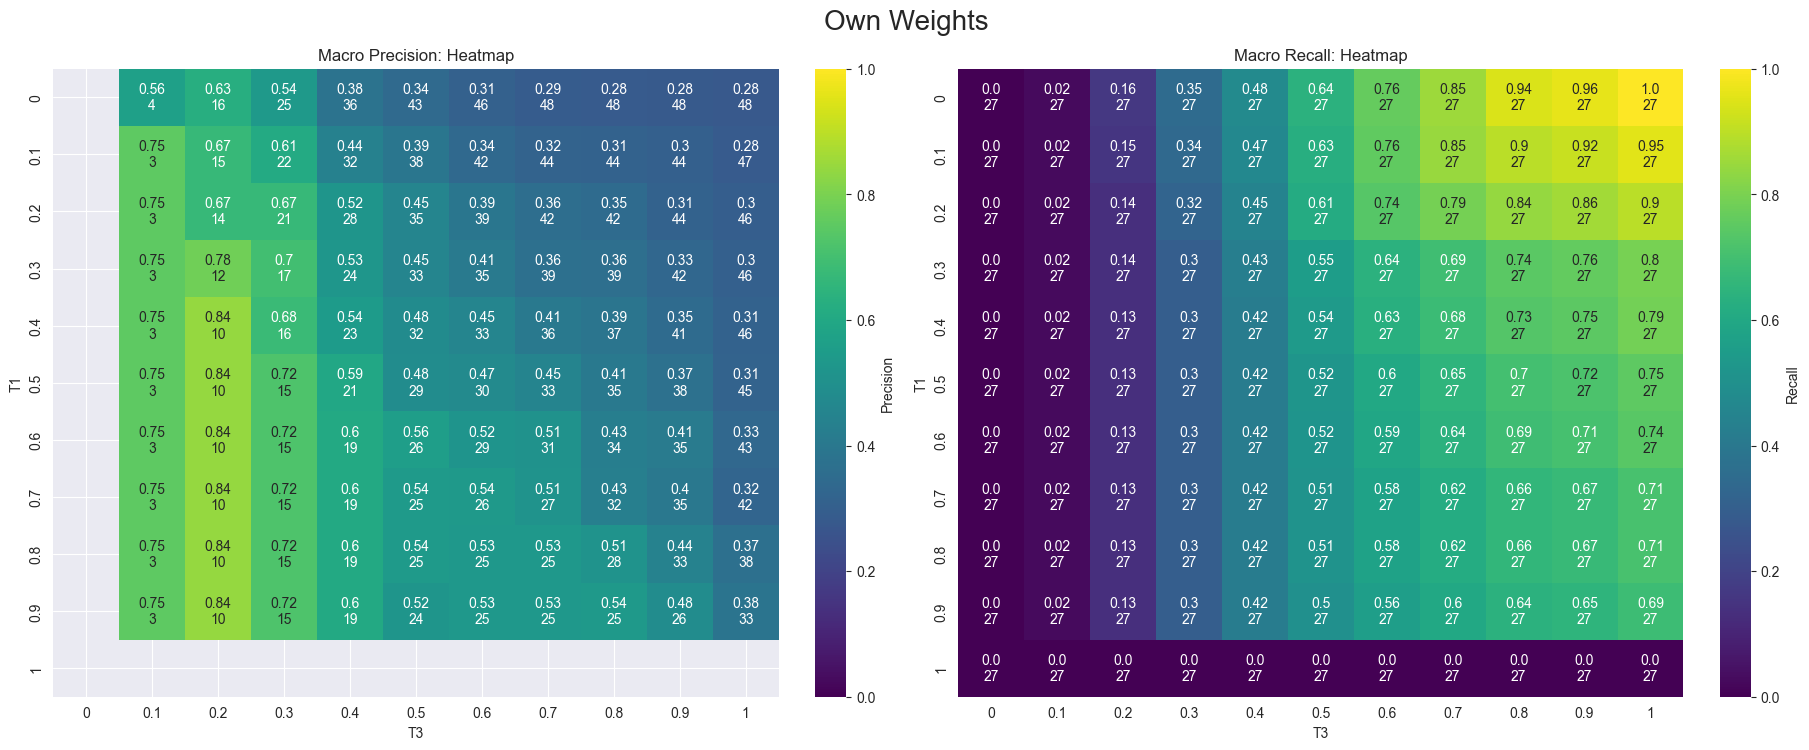

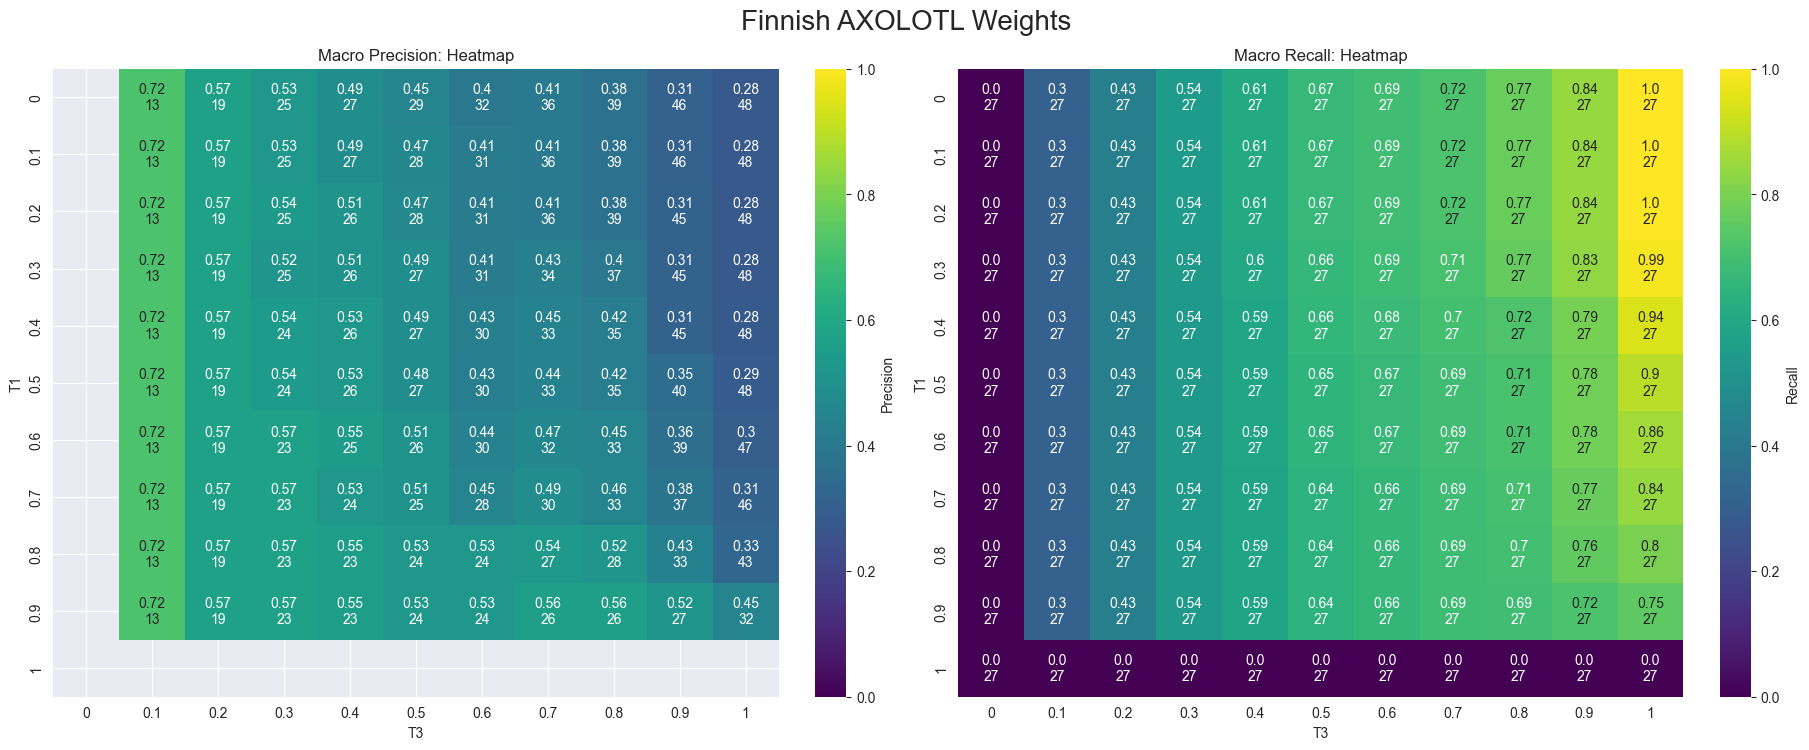

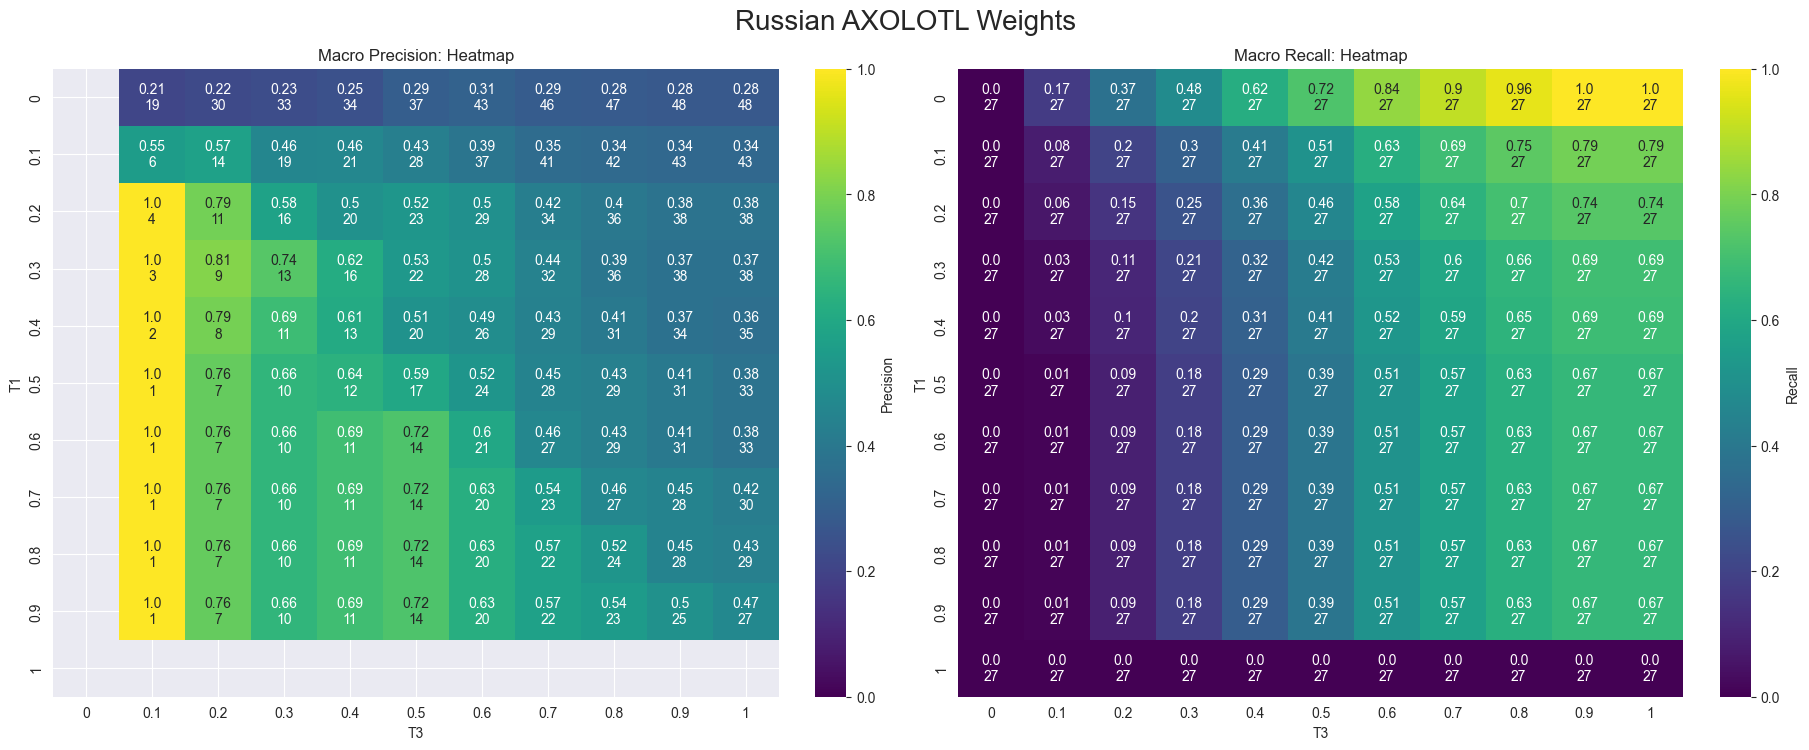

In [18]:
if show_sense_counts:
    print(f"In each cell find the respective metric with the number of senses involved in calculation of metric below")
with PdfPages(pdf_out) as pdf:
    for result in result_inputs:
        df_target_res = df_results[df_results["result_name"] == result.name]

        height = 7 if show_sense_counts else 5
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, height), constrained_layout=True)
        axes = axes.flatten()

        fig.suptitle(f"{result.name}", fontsize=20, y=1.05)
        pivot_precision = df_target_res.pivot(index="t1", columns="t3", values="Precision")
        pivot_recall = df_target_res.pivot(index="t1", columns="t3", values="Recall")

        if show_sense_counts:
            valid_precision_count = df_target_res.pivot(index="t1", columns="t3", values="valid_p_count")
            valid_recall_count = df_target_res.pivot(index="t1", columns="t3", values="valid_r_count")
            cell_contents_precision = pivot_precision.round(2).astype(str) + "\n" + valid_precision_count.astype(str)
            cell_contents_recall = pivot_recall.round(2).astype(str) + "\n" + valid_recall_count.astype(str)
        else:
            cell_contents_precision = pivot_precision.round(2).astype(str)
            cell_contents_recall = pivot_recall.round(2).astype(str)
        sns.heatmap(pivot_precision, annot=cell_contents_precision.values, fmt="", cmap="viridis", cbar_kws={'label': "Precision"}, ax=axes[0], vmin=0, vmax=1)
        sns.heatmap(pivot_recall, annot=cell_contents_recall.values, fmt="", cmap="viridis", cbar_kws={'label': "Recall"}, ax=axes[1], vmin=0, vmax=1)
        axes[0].set_title(f"Macro Precision: Heatmap")
        axes[1].set_title(f"Macro Recall: Heatmap")

        for ax in axes:
            ax.set_xlabel("T3")
            ax.set_ylabel("T1")

        pdf.savefig(fig, bbox_inches='tight')
        plt.show()
        plt.close(fig)

In [19]:
# recalculate precision and recall with different thresholds
results = []

# try to map values back to their original threshold
def get_original_thresh(threshold: float, prob_mapping: dict) -> float:
    normalized_probs = prob_mapping.keys()
    greater_probs = [p for p in normalized_probs if p > threshold]
    smaller_probs = [p for p in normalized_probs if p < threshold]
    if smaller_probs and greater_probs:
        return (prob_mapping[min(greater_probs)] + prob_mapping[max(smaller_probs)]) / 2
    elif smaller_probs and not greater_probs:
        return prob_mapping[max(smaller_probs)] + 1e-10
    elif not smaller_probs and greater_probs:
        return prob_mapping[min(greater_probs)] - 1e-10
    else:
        print("error.")
        sys.exit(1)

for result in result_inputs:
    # read required result files
    s1_raw_results = glob.glob(result.path + "/s1/result_raw.tsv")
    s3_raw_results = glob.glob(result.path + "/s3/result_raw.tsv")
    if not s1_raw_results:
        print(f"could not find /s1/result_raw.tsv in {result.path}")
        sys.exit(1)
    if not s3_raw_results:
        print(f"could not find /s3/result_raw.tsv in {result.path}")
        sys.exit(1)
    df_s1_raw_results = pd.read_csv(s1_raw_results[0], sep="\t", encoding="utf-8", dtype={"identifier": str, "sense_id": str, "lemma": str, "prob": float})[["identifier", "lemma", "prob"]]
    df_s3_raw_results = pd.read_csv(s3_raw_results[0], sep="\t", encoding="utf-8", dtype={"identifier": str, "sense_id": str, "lemma": str, "prob": float})[["identifier", "lemma", "prob", "sense_id"]].rename(columns={"sense_id": "prediction_id"})

    s1_prob_mapping = {s1_prob: s1_prob for s1_prob in df_s1_raw_results["prob"].tolist()}
    s3_prob_mapping = {s3_prob: s3_prob for s3_prob in df_s3_raw_results["prob"].tolist()}

    # normalize probs using quantile transformer
    if result.normalize_probs:
        qt = QuantileTransformer(n_quantiles=100, output_distribution="uniform", random_state=0)
        probs_s1 = qt.fit_transform(df_s1_raw_results["prob"].to_numpy().reshape(-1, 1)).ravel()
        probs_s3 = qt.fit_transform(df_s3_raw_results["prob"].to_numpy().reshape(-1, 1)).ravel()
        eps = 1e-6
        probs_s1 = np.clip(probs_s1, eps, 1 - eps)
        probs_s3 = np.clip(probs_s3, eps, 1 - eps)

        # store mappings to later map back and recompute a threshold
        s1_prob_mapping = {s1_new: s1_original for s1_original, s1_new in zip(df_s1_raw_results["prob"].tolist(), probs_s1)}
        s3_prob_mapping = {s3_new: s3_original for s3_original, s3_new in zip(df_s3_raw_results["prob"].tolist(), probs_s3)}
        df_s1_raw_results["prob"] = probs_s1
        df_s3_raw_results["prob"] = probs_s3

    # merge results with annotated_usages
    df_s1_merged = df_annotation.merge(df_s1_raw_results, on=["lemma", "identifier"], how="inner").copy()
    df_s3_merged = df_annotation.merge(df_s3_raw_results, on=["lemma", "identifier"], how="inner").copy()
    df_lemur_base = df_lemur.copy()

    # apply filters if specified
    if result.in_ode is not None:
        df_s1_merged = df_s1_merged[df_s1_merged["in_ode"] == result.in_ode].copy()
        df_s3_merged = df_s3_merged[df_s3_merged["in_ode"] == result.in_ode].copy()
        df_lemur_base = df_lemur_base[df_lemur_base["in_ode"] == result.in_ode].copy()
    if result.mwe is not None:
        df_s1_merged = df_s1_merged[df_s1_merged["mwe"] == result.mwe].copy()
        df_s3_merged = df_s3_merged[df_s3_merged["mwe"] == result.mwe].copy()
        df_lemur_base = df_lemur_base[df_lemur_base["mwe"] == result.mwe].copy()

    ids = set(df_s1_raw_results["identifier"].tolist())
    df_annotation_filtered = df_annotation[df_annotation["identifier"].isin(ids)]

    # for each combination of specified thresholds calculate metrics

    t1_thresholds = per_considered_senses_thresholds
    if result.no_s1:
        t1_thresholds = [0.0]
    for t1 in t1_thresholds:
        for t3 in per_considered_senses_thresholds:
            df_s1_filtered = df_s1_merged[df_s1_merged["prob"] > t1].copy()
            df_s3_filtered = df_s3_merged[df_s3_merged["identifier"].isin(df_s1_filtered["identifier"].tolist())].copy()
            precision, recall, valid_p, valid_r = calc_metrics(df_annotation_filtered,  df_s3_filtered, t3, df_lemur_base)
            results.append({"Precision": precision, "Recall": recall, "result_name": result.name, "t1": str(t1), "t3": str(t3), "valid_p_count": valid_p, "valid_r_count": valid_r, "t1_original": get_original_thresh(t1, s1_prob_mapping), "t3_original": get_original_thresh(t3, s3_prob_mapping)})
df_results_per_sense_count = pd.DataFrame(results)

In [20]:
# save data to file so it can be used to plot outside this notebook
plot_data = []
for model_name, model_rows in df_results_per_sense_count.groupby("result_name"):
    model_rows_clean = model_rows.dropna(subset=["Precision", "valid_p_count", "Recall"])
    if model_rows_clean.empty:
        continue
    # For each number of considered senses, get the highest possible precision, recall is second decider
    for valid_count, target_count_rows in model_rows_clean.groupby("valid_p_count"):
        highest_precision_rows = target_count_rows[target_count_rows["Precision"] == target_count_rows["Precision"].max()]
        best_row = highest_precision_rows[highest_precision_rows["Recall"] == highest_precision_rows["Recall"].max()].iloc[[0]].copy()
        best_row["model"] = model_name
        plot_data.append(best_row)
df_plot = pd.concat(plot_data)
df_plot.to_csv("../plots/raw_results/" + raw_result_name, sep="\t", index=False)

In [21]:
colors = px.colors.qualitative.Dark24
all_result_names = df_results_per_sense_count["result_name"].unique()
color_map = {result: colors[num % 24] for num, result in enumerate(all_result_names)}


plot_data = []
for model_name, model_rows in df_results_per_sense_count.groupby("result_name"):
    model_rows_clean = model_rows.dropna(subset=["Precision", "valid_p_count", "Recall"])
    if model_rows_clean.empty:
        continue
    # For each number of considered senses, get the highest possible precision, recall is second decider
    for valid_count, target_count_rows in model_rows_clean.groupby("valid_p_count"):
        highest_precision_rows = target_count_rows[target_count_rows["Precision"] == target_count_rows["Precision"].max()]
        best_row = highest_precision_rows[highest_precision_rows["Recall"] == highest_precision_rows["Recall"].max()].iloc[[0]].copy()
        best_row["model"] = model_name
        plot_data.append(best_row)
df_plot = pd.concat(plot_data)
plotly_fig = go.Figure()

for model_name, per_model_rows in df_plot.groupby("model"):
    model_color = color_map[model_name]
    # Precision = solid
    plotly_fig.add_trace(go.Scatter(x=per_model_rows["valid_p_count"], y=per_model_rows["Precision"], mode="lines+markers", name=model_name, legendgroup=model_name, line=dict(color=model_color, dash="solid"), marker=dict(color=model_color), customdata=np.stack((per_model_rows["t1_original"], per_model_rows["t3_original"] ), axis=-1), hovertemplate="<b>%{text}</b><br>" "Valid senses: %{x}<br>" "Precision: %{y:.3f}<br>" "T1: %{customdata[0]:.3f}<br>" "T3: %{customdata[1]:.3f}<extra></extra>", text=[model_name] * len(per_model_rows)))
    plotly_fig.add_trace(go.Scatter(x=per_model_rows["valid_p_count"], y=per_model_rows["Recall"], mode="lines+markers", name=model_name, legendgroup=model_name, line=dict(color=model_color, dash="dash"), marker=dict(color=model_color), showlegend=False, customdata=np.stack((per_model_rows["t1_original"], per_model_rows["t3_original"]), axis=-1), hovertemplate="<b>%{text}</b><br>" "Valid senses: %{x}<br>" "Recall: %{y:.3f}<br>" "T1: %{customdata[0]:.3f}<br>" "T3: %{customdata[1]:.3f}<extra></extra>", text=[model_name] * len(per_model_rows)))

plotly_fig.update_layout(width=1400, height=600)
display(Markdown("### Best Macro Precision and Respective Recall for each number of senses used in calculation of the Macro Precision Metric"))
plotly_fig.show()
plotly_fig.write_html(html_out)
print(f"Click names in legend to de-/activate. Also saved as html to {html_out}")
display(Markdown(f"Macro prediction can only be calculated for senses for which the model made at least 1 prediction. Number of senses considered in the calculation of Macro Precision is relevant as a high precision for a small number of senses does not mean much. The following plot shows for the number of considered senses on the x axis the best precision and the respective recall value for that datapoint."))

### Best Macro Precision and Respective Recall for each number of senses used in calculation of the Macro Precision Metric

Click names in legend to de-/activate. Also saved as html to ../plots/threshold_analysis/regular_lemur/regular/pr_sense_count.html


Macro prediction can only be calculated for senses for which the model made at least 1 prediction. Number of senses considered in the calculation of Macro Precision is relevant as a high precision for a small number of senses does not mean much. The following plot shows for the number of considered senses on the x axis the best precision and the respective recall value for that datapoint.

In [22]:
plotly_fig = make_subplots(rows=1, cols=2, subplot_titles=("Precision", "Recall"))
colors = px.colors.qualitative.Dark24
all_result_names = df_results_per_sense_count["result_name"].unique()
color_map = {result: colors[num%24] for num, result in enumerate(all_result_names)}

plot_data = []
for model_name, group in df_results_per_sense_count.groupby("result_name"):
    # drop rows with NaNs in Precision or valid_p_count
    group_clean = group.dropna(subset=["Precision", "valid_p_count", "Recall"])
    if group_clean.empty:
        continue
    # For each number of considered senses, get the highest possible precision
    idx = group_clean.groupby("valid_p_count")["Precision"].idxmax()
    max_precision_points = group_clean.loc[idx]
    max_precision_points["model"] = model_name
    plot_data.append(max_precision_points)
df_plot = pd.concat(plot_data)

for model_name, per_model_rows in df_plot.groupby("model"):
    model_color = color_map[model_name]
    plotly_fig.add_trace(go.Scatter(x=per_model_rows["valid_p_count"], y=per_model_rows["Precision"], mode="lines+markers", name=model_name, legendgroup=model_name, line=dict(color=model_color), marker=dict(color=model_color)), row=1, col=1)
    plotly_fig.add_trace(go.Scatter(x=per_model_rows["valid_p_count"], y=per_model_rows["Recall"], mode="lines+markers", name=model_name, legendgroup=model_name, line=dict(color=model_color), marker=dict(color=model_color), showlegend=False), row=1, col=2)
plotly_fig.update_layout(width=1400, height=600)
display(Markdown("### Best Macro Precision and Respective Recall for each number of senses used in calculation of the Macro Precision Metric"))
plotly_fig.show()
print(f"Click names in legend to de-/activate. Also saved as html to {html_out_separate}")
plotly_fig.write_html(html_out_separate)

### Best Macro Precision and Respective Recall for each number of senses used in calculation of the Macro Precision Metric

Click names in legend to de-/activate. Also saved as html to ../plots/threshold_analysis/regular_lemur/regular/pr_sense_count_separate.html
